# Education based on conversation


Notes on the transcript types
- M01: life map
- N01: field notes
- TL01: time log
- F01: transcription (track)

In [57]:
%pip install gdown pandas numpy seaborn matplotlib PyPDF2 openpyxl

Note: you may need to restart the kernel to use updated packages.


In [58]:
# Import files using a zip folder instead of mounting drive for security

import gdown
import zipfile

# https://drive.google.com/file/d/1SxW-AGcDaE-tO5JgW-IDQLR3DESsVn8X/view?usp=drive_link
file_id = '1SxW-AGcDaE-tO5JgW-IDQLR3DESsVn8X'       # file ID from share link
output_filename = 'raw_interview_transcripts.zip'

try:
    gdown.download(id=file_id, output=output_filename, quiet=False)
    print(f"File '{output_filename}' downloaded successfully.")
except Exception as e:
    print(f"An error occurred during download: {e}")

with zipfile.ZipFile('raw_interview_transcripts.zip', 'r') as zip_ref:
    zip_ref.extractall()


Downloading...
From (original): https://drive.google.com/uc?id=1SxW-AGcDaE-tO5JgW-IDQLR3DESsVn8X
From (redirected): https://drive.google.com/uc?id=1SxW-AGcDaE-tO5JgW-IDQLR3DESsVn8X&confirm=t&uuid=0873996a-fafd-4130-9dc0-4f79985973a2
To: /Users/rlay/work/26s-curric-803-report/raw_interview_transcripts.zip
100%|██████████| 120M/120M [00:02<00:00, 52.9MB/s] 


File 'raw_interview_transcripts.zip' downloaded successfully.


In [59]:
# datascience libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# file handling libs
import os
import PyPDF2
import re

In [60]:
# load pdf file names into a list, only including F01 (transcription notes)
pdf_dir = './individual_transcripts/'

pdf_files = [os.path.join(pdf_dir, f) for f in os.listdir(pdf_dir) if f.lower().endswith('.pdf') and "F" in f]
pdf_files_lifemap = [os.path.join(pdf_dir, f) for f in os.listdir(pdf_dir) if f.lower().endswith('.pdf') and "M" in f.upper()]
# verify files loaded
print(f"Found {len(pdf_files)} PDF files:")
for pdf_file in pdf_files[:5]:
    print(pdf_file)
print(f"Found {len(pdf_files_lifemap)} PDF files:")
for pdf_file in pdf_files_lifemap[:5]:
    print(pdf_file)

pdf_files.sort()
pdf_files_lifemap.sort()

Found 285 PDF files:
./individual_transcripts/VAOHP0101_F01.pdf
./individual_transcripts/VAHF0002_F01.pdf
./individual_transcripts/VAOHP0111_F01.pdf
./individual_transcripts/VAOHP0069_F01.pdf
./individual_transcripts/VAHF0010_F01_Eng.pdf
Found 54 PDF files:
./individual_transcripts/VAOHP0373_M01.pdf
./individual_transcripts/VAOHP0363_M01.pdf
./individual_transcripts/VAOHP0260_M01.pdf
./individual_transcripts/VAOHP0355_M01.pdf
./individual_transcripts/VAOHP0261_M01.pdf


In [61]:
def extract_text_from_pdf(pdf_path):
    """
    Extracts all text content from a given PDF file.

    Args:
        pdf_path (str): The path to the PDF file.

    Returns:
        str: The extracted text content, or an empty string if an error occurs.
    """
    text_content = ''
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text_content += page.extract_text() + '\n'
        return text_content
    except FileNotFoundError:
        print(f"Error: File not found at {pdf_path}")
        return ""
    except Exception as e:
        print(f"Error extracting text from '{pdf_path}': {e}")
        return ""

In [62]:
# verify files have contents
first_pdf_file = pdf_files[0]
if first_pdf_file:
    first_pdf_extracted_text = extract_text_from_pdf(first_pdf_file)
    if first_pdf_extracted_text:
        print(f"Successfully extracted text from '{first_pdf_file}' using the function.\nFirst 500 characters of text:\n")
        display(f"{first_pdf_extracted_text[:500]}...")
    else:
        print(f"Failed to extract text from '{first_pdf_file}' using the function.")
else:
    print("No PDF files found to test the function with.")

Successfully extracted text from './individual_transcripts/VAHF0001_F01_Eng.pdf' using the function.
First 500 characters of text:



'VAHF0001\t\r \xa0\t\r \xa01\t\r \xa0Vietnamese American Heritage Foundation & Vietnamese American Oral History Project, UC Irvine  Narrator: HỒ VĂN KHỞI Interviewer: Nancy Bùi Date: May 25, 2010 Location: San Jose, California Length of Interview:  00:50:51 Sub-collection: Vietnamese American Heritage Foundation 500 Oral Histories Transcriber: Khanh Bui Translator: Quynh Chi Kim  NB: Hello Sir!  Would you please introduce your name and place of birth? HVK: I’m Hồ Văn Khởi.  I was born in Gò Công, Việt Nam. NB: ...'

In [63]:
columns = [
    # hard metadata
    'interview_id',
    'narrator_name',
    'narrator_initials',
    'interviewer_name',
    'interviewer_initials',
    'date',
    'location',
    'interview_length',
    'sub-collection',
    'narrator_dialogue',
    'interviewer_dialogue',
    # inferred metadata
    'wave',
    'generation',
    'gender',
    'age',
    'birth_year',
    'birthplace',
    'year_left_country',
    'year_of_arrival',
    'refugee_cohort',
    'highest_education',
]
df = pd.DataFrame(columns=columns)
print("Empty DataFrame created with specified columns:")
print(df.head())

Empty DataFrame created with specified columns:
Empty DataFrame
Columns: [interview_id, narrator_name, narrator_initials, interviewer_name, interviewer_initials, date, location, interview_length, sub-collection, narrator_dialogue, interviewer_dialogue, wave, generation, gender, age, birth_year, birthplace, year_left_country, year_of_arrival, refugee_cohort, highest_education]
Index: []

[0 rows x 21 columns]


In [64]:
def _remove_filename_from_text(text_content, file_name):
    """
    Removes the file name from the raw text content of the PDF and detects language
    
    Args:
        text_content (str): The raw text content extracted from a PDF.
        file_name (str): The name of the PDF file.

    Returns:
        tuple: A tuple containing (cleaned_text_content, language)
    """

    # Detect language based on filename patterns
    if 'viet' in file_name.lower():
        language = 'Vietnamese'
    elif 'cantonese' in file_name.lower():
        language = 'Cantonese'
    else:
        language = 'English'
    
    # trim file_name to remove directory and file extensions
    # r'/([^\/]+?)_F01' regex to select specifically the part between rawcontent/{target}_F01
    file_name = file_name.replace(f"{os.path.dirname(file_name)}/", '')
    file_name = file_name.replace('_F01.pdf', '')
    file_name = file_name.replace('_F01.docx.pdf', '')
    file_name = re.sub(r'/([^\/]+?)_F01', '', file_name)
    text_content = re.sub(fr"{file_name}\d+", "", text_content)
    
    return text_content, language

# test
cleaned_text, detected_language = _remove_filename_from_text(first_pdf_extracted_text, pdf_files[7])
display(cleaned_text)
display(f"Detected language: {detected_language}")
display(pdf_files[7])

'VAHF0001\t\r \xa0\t\r \xa01\t\r \xa0Vietnamese American Heritage Foundation & Vietnamese American Oral History Project, UC Irvine  Narrator: HỒ VĂN KHỞI Interviewer: Nancy Bùi Date: May 25, 2010 Location: San Jose, California Length of Interview:  00:50:51 Sub-collection: Vietnamese American Heritage Foundation 500 Oral Histories Transcriber: Khanh Bui Translator: Quynh Chi Kim  NB: Hello Sir!  Would you please introduce your name and place of birth? HVK: I’m Hồ Văn Khởi.  I was born in Gò Công, Việt Nam. NB: What year were you born? HVK: I was born in 1949. NB: So did you grow up in Gò Công or in Sài Gòn? HVK: I lived there when I was young.  I went to elementary school there in Gò Công, in the countryside, but when I went to high school as I grew up I came to Saigon. NB: Do you have any precious memory of Gò Công that you want to share? HVK: When I was young my family was very poor, so I went to school and took care of my siblings; therefore, I hardly had any children’s game, and if

'Detected language: English'

'./individual_transcripts/VAHF0005_N01.pdf'

In [65]:
def _initialize_metadata():
    """
    Initializes the metadata dictionary with None values.
    """
    return {
        # read metadata
        'file_name': None,
        'interview_id': None,
        'narrator_name': None,
        'interviewer_name': None,
        'date': None,
        'location': None,
        'language_written': None,
        'language_spoken': None,
        'interview_length': None,
        'sub-collection': None,
        'narrator_initials': None,
        'interviewer_initials': None,
        'narrator_dialogue': None,
        'narrator_dialogue_character_count': None,
        'interviewer_dialogue': None,
        'interviewer_dialogue_character_count': None,
        # inferred metadata
        'wave': None,
        'generation': None,
        'gender': None,
        'age': None,
        'birth_year': None,
        'birthplace': None,
        'year_left_country': None,
        'year_of_arrival': None,
        'refugee_cohort': None,
        'highest_education': None,
    }

In [66]:
def _get_metadata_patterns():
    """
    Defines and returns regular expression patterns for each metadata field.
    """
    return {
        'narrator_name': r"Narrator:([\s\S]*?)(?:Interviewer:|Date:|Location:|Sub-Collection:|Length of Interview:|$)",
        'interviewer_name': r"Interviewer:([\s\S]*?)(?:Date:|Location:|Sub-Collection:|Length of Interview:|$)",
        'date': r"Date:([\s\S]*?)(?:Location:|Sub-Collection:|Length of Interview:|$)",
        'location': r"Location:([\s\S]*?)(?:Sub-Collection:|Length of Interview:|$)",
        'interview_length': r"Length of Interview:\s+(\d{2}:\d{2}:\d{2})",
    }

In [67]:
def extract_sub_collection_simple(text):
    parts = text.lower().split("sub-collection:")
    if len(parts) < 2:
        return None
    
    content = parts[1]
    # Find the next line that starts with a known field
    for line in content.split('\n'):
        if any(line.strip().lower().startswith(field) for field in ["length of interview:", "transcriber:", "location:"]):
            return content[:content.find(line)].strip()
    
    return content.strip()
# Example usage
text = """Location: Westminster, California
Sub-collection: Vietnamese American Heritage Foundation 500 Oral Histories
Length of Interview: 00:12:13
Transcriber: Grace Ho"""
 
sub_collection = extract_sub_collection_simple(text)
print(sub_collection)  # "Vietnamese American Heritage Foundation 500 Oral Histories"

vietnamese american heritage foundation 500 oral histories


In [68]:
def _extract_initial_fields(text_content, patterns):
    """
    Extracts initial metadata fields from the given text content using the provided patterns.
    """
    metadata = _initialize_metadata()
    for key, pattern in patterns.items():
        match = re.search(pattern, text_content, re.IGNORECASE | re.DOTALL)
        if match:
            metadata[key] = match.group(1).strip()
    metadata['sub-collection'] = extract_sub_collection_simple(text_content)
    return metadata

In [69]:
def _refine_name_field(name_string):
    """
    Refines narrator_name or interviewer_name by truncating extraneous text.
    """
    return name_string.lower().title()

In [70]:
def _clean_all_values(data):
    """
    Cleans up residual newlines or extra spaces in all extracted string values in a dictionary.
    """
    for key, value in data.items():
        if value and isinstance(value, str):
            data[key] = re.sub(r'\s+', ' ', value).strip()
    return data

In [71]:
def _extract_dialogue_section(text_content):
    """
    Extracts the dialogue section of the transcript.
    If not found, it tries to find the start of the first speaker turn.

    Args:
        text_content (str): The full text content of the PDF.

    Returns:
        str: The dialogue section, or an empty string if no clear dialogue start is found.
    """
    # This assumes dialogue starts with a speaker's initials (e.g., NDM:, PCN:).
    # The regex grabs any 2+ uppercase letters followed by a colon
    speaker_initials_pattern = re.compile(r'[A-Z]{2,}:', re.DOTALL)
    match = speaker_initials_pattern.search(text_content)
    if match:
        # Start dialogue from the beginning of the first identified speaker initial
        return text_content[match.start():].strip()
    else:
        # If neither initials are found, we cannot reliably determine
        # the start of the dialogue, so return an empty string.
        return ""

In [72]:
def _extract_actual_speaker_initials(text_content):
    """
    Parses the dialogue section to identify the interviewer's initials
    (the first initial found) and the narrator's initials (the second distinct initial found).

    Args:
        text_content (str): The full text content of the PDF.

    Returns:
        tuple: A tuple containing (narrator_initials, interviewer_initials).
    """
    narrator_initials = None
    interviewer_initials = None

    dialogue_section_full = _extract_dialogue_section(text_content)

    if not dialogue_section_full:
        return (None, None)

    speaker_initials_pattern = re.compile(r'\b([A-Z]{2,5})\s*:')
    matches = list(speaker_initials_pattern.finditer(dialogue_section_full))

    # Collect all unique speaker initials
    unique_speakers = []
    for match in matches:
        current_initials = match.group(1)
        if current_initials not in unique_speakers:
            unique_speakers.append(current_initials)

    # Assign roles based on order and count
    if len(unique_speakers) >= 1:
        interviewer_initials = unique_speakers[0]  # First speaker is interviewer
    if len(unique_speakers) >= 2:
        narrator_initials = unique_speakers[1]     # Second speaker is primary narrator

    return (narrator_initials, interviewer_initials)

In [73]:
def _parse_speakers_dialogue(dialogue_text, narrator_initials, interviewer_initials):
    """
    Parses the dialogue text and attributes lines to narrator and interviewer
    based on their initials.

    Args:
        dialogue_text (str): The extracted dialogue section of the transcript.
        narrator_initials (str): The initials of the narrator.
        interviewer_initials (str): The initials of the interviewer.

    Returns:
        tuple: A tuple containing (narrator_dialogue_list, interviewer_dialogue_list),
               where each is a list of their respective dialogue segments.
    """
    narrator_dialogue_list = []
    interviewer_dialogue_list = []

    if not narrator_initials or not interviewer_initials:
        raise ValueError(f"failing due to bad initials {narrator_initials = }\t{interviewer_initials = }")

    # Clean non-breaking spaces from dialogue text
    dialogue_text = dialogue_text.replace('\xa0', ' ')
    dialogue_text = dialogue_text.replace('\t\r', '')

    narrator_init_esc = re.escape(narrator_initials)
    interviewer_init_esc = re.escape(interviewer_initials)

    # Create speaker pattern for all speakers
    speaker_pattern = f"{narrator_init_esc}|{interviewer_init_esc}"

    # Regex to find speaker turns: (SpeakerInitials:)(DialogueText)
    # The non-greedy match (.*?) captures dialogue until the next speaker initial or end of string.
    # The lookahead `(?= ... |$)` ensures that the delimiter itself is not consumed by the match,
    # allowing subsequent matches to start correctly.
    speaker_turn_pattern = re.compile(
        rf"([A-Z]{{2,}}:)(.*?)(?=([A-Z]{{2,}}:)|$)",
        # rf"({speaker_pattern}:)(.*?)(?=(?:{speaker_pattern}:)|$)",
        
        re.MULTILINE
    )

    for match in speaker_turn_pattern.finditer(dialogue_text):
        speaker_id = match.group(1).strip() # e.g., "NL:", "MHL:"
        dialogue_segment = match.group(2).strip()

        if speaker_id == f"{interviewer_initials}:":
            interviewer_dialogue_list.append(dialogue_segment)
        else:
            narrator_dialogue_list.append(dialogue_segment)
    
    # Convert lists to strings
    narrator_dialogue_str = ' '.join(narrator_dialogue_list)
    interviewer_dialogue_str = ' '.join(interviewer_dialogue_list)
    
    return narrator_dialogue_str, interviewer_dialogue_str

In [74]:
# not using this because this wouldnt improve the NN at all!
def _handle_multiple_narrators(text_content, file_name):
    # handle edge case of multiple narrators by duplicating metadata, separating
    # into two different rows
    # VAOHP0137
    # VAOHP0140
    # VAOHP0167
    if file_name in ["VAOHP0137", "VAOHP0140", "VAOHP0167"]:
        # identify if the initials belong the narrators or the interviewer
        # TODO: split text_content into two parts, one for each narrator
        # TODO: create two separate dictionaries for each narrator
        # TODO: return both dictionaries
        pass

    return text_content

In [75]:
tester_text = extract_text_from_pdf('./individual_transcripts/VAOP0358_F01.pdf')
# tester_text = extract_text_from_pdf(pdf_files[2])
print('./individual_transcripts/VAOP0358_F01.pdf')
display(tester_text)


./individual_transcripts/VAOP0358_F01.pdf


'VAOHP0358 1  \n Vietnamese American Oral History Project, UC Irvine  Narrator: HIEU NHU NGUYEN Interviewer: Kelley Thu Ho Date: February 15th, 2019 Location: Garden Grove, California Sub-collection: Vietnamese American Experience Class Oral Histories, Winter 2019 Length of Interview: 1:03:34  (00:00)  KH: This is Kelley Ho with VietStories: Vietnamese American Oral History Project at UC [University of California] Irvine. Today is February 15th, 2019. I will be interviewing Hieu Nguyen at 102 Cafe in Garden Grove, California. Hi Hieu (laughs).  HN: Hello.  (00:19)   KH: Hi. Can we start by saying your name, your age, and where you currently live?   HN: Uh, Hieu Nguyen. I\'m 34. And I currently live in Garden Grove, California.  (00:31)  KH: And can you tell me a little bit about what you do now?  HN: Ah so professionally I\'m a licensed clinical social worker and I work for APAIT which stands for Asian Pacific AIDS [acquired immunodeficiency syndrome] Intervention Team. Um, and I also 

In [76]:
def _extract_birth_year(text: str, interview_year: int | str | None = None) -> int:
    """
    Extract birth year from text, taking into account age if interview year is known.
    
    Args:
        text: Text to extract birth information from
        interview_year: Interview year or None
        
    Returns:
        Birth year string
    """
    if interview_year is None:
        interview_year = 0
    if isinstance(interview_year, str):
        date_match = re.search(r"\b(\d{4})\b", interview_year)
        if date_match:
            # print(f"Found date match: {date_match.group(1)}")
            interview_year = int(date_match.group(1))
        else:
            interview_year = 0
    
    # Common patterns for birth year in transcripts
    year_patterns = [
        # VKB: What is your date of birth? AHL: 11/28/81.
        r"birth.*?(\d{2}/\d{2}/\d{2})",
        # "date of birth is April 6, 1966"
        r"(?:date of birth|born|birth).*?(\d{4})",
        # "born in 1970"
        r"born in (\d{4})",
        # "birth year: 1966"
        r"birth year[:\s]+(\d{4})"
    ]
    
    # calculate approximate birth year
    age_patterns = [
        # "age 46" 
        r"(?:age|I'm|I am)[\s]+(\d{2})",
        # "64 years old"
        r"(\d{2}) years old"
    ]
    
    for pattern in year_patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        found_match = next((match for match in matches if match.strip().isdigit() and 1900 <= int(match.strip()) <= 2020), None)
        if found_match:
            return int(found_match.strip())
    
    for pattern in age_patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        found_match = next((match for match in matches if match.strip().isdigit()), None)
        if found_match and interview_year:
            return int(interview_year) - int(found_match.strip())

    return 0

display(_extract_birth_year(tester_text, interview_year="March 15, 2012; March 18, 2012"))
tester_birth_year = int(_extract_birth_year(tester_text, interview_year=2019))
display(tester_birth_year)

1978

1985

In [77]:
def _extract_year_left_country(text: str) -> int:
    """
    Extract the year the participant left their country of origin.
    
    Args:
        text (str): The transcript text to search
        
    Returns:
        int: The extracted year or None if not found
    """
    
    # Common patterns for when someone left their country
    patterns = [
        # "escaped to the U.S. in 1975" - more flexible
        r"escaped.*?to.*?in (\d{4})",
        # "left Vietnam in 1983"
        r"left.*?(?:Vietnam|country).*?in (\d{4})",
        # "I left in 1983"
        r"(?:I|we) left.*?in (\d{4})",
        # "departed in 1975"
        r"departed.*?in (\d{4})",
        # "escaped in 1979"
        r"escaped.*?in (\d{4})",
        # "fled in 1978"
        r"fled.*?in (\d{4})",
        # "when I left in 1983"
        r"when.*?left.*?(\d{4})",
        # "year I left: 1983"
        r"(?:year|time).*?left[:\s]+(\d{4})",
        # Direct 4-digit year patterns in context of leaving (more specific)
        r"(?:left|departed|escaped|fled).*?(\d{4})",
        # "in 1983 I left"
        r"in (\d{4}).*?(?:left|departed|escaped|fled)",
        # "came here in 1975" - common phrasing
        r"came here.*?in (\d{4})",
        # "arrived in 1975" - might refer to arrival but could be departure context
        r"arrived.*?in (\d{4})",
        # "went in 1975"
        r"went.*?in (\d{4})",
        # "'ve lived here in Garden Grove ever since 1993."
        r"lived.*?here.*?since (\d{4})",
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        # Find valid year matches (reasonable range for Vietnamese immigration)
        found_match = next((match for match in matches if match.strip().isdigit() and 1950 <= int(match.strip()) <= 2020), None)
        if found_match:
            return int(found_match.strip())
    
    return None

display(_extract_year_left_country(tester_text))

1993

In [78]:
def _extract_year_of_arrival(text: str) -> int | None:
    """
    Extract the year the participant arrived in the US.
    
    Args:
        text (str): The transcript text to search
        
    Returns:
        str: The extracted year or empty string if not found
    """
    
    # Common patterns for when someone arrived in the US
    patterns = [
        # "arrived in the US in 1975"
        r"arrived.*?(?:the US|United States|America|here).*?in (\d{4})",
        # "settled here in 1975"
        r"settled.*?(?:here|the US|United States|America).*?in (\d{4})",
        # "immigrated to the US in 1975"
        r"immigrated.*?(?:to the US|to the United States|to America).*?in (\d{4})",
        # "came to the US in 1975"
        r"came.*?(?:to the US|to the United States|to America|here).*?in (\d{4})",
        # "moved to the US in 1975"
        r"moved.*?(?:to the US|to the United States|to America).*?in (\d{4})",
        # "I arrived in 1975"
        r"(?:I|we) arrived.*?in (\d{4})",
        # "when I arrived in 1975"
        r"when.*?arrived.*?(\d{4})",
        # "year I arrived: 1975"
        r"(?:year|time).*?arrived[:\s]+(\d{4})",
        # Direct 4-digit year patterns in context of arrival
        r"(?:arrived|settled|immigrated|came).*?(\d{4})",
        # "in 1975 I arrived"
        r"in (\d{4}).*?(?:arrived|settled|immigrated|came)",
        # "arrived here in 1975"
        r"arrived here.*?in (\d{4})",
        # "came to America in 1975"
        r"came to America.*?in (\d{4})",
        # "reached the US in 1975"
        r"reached.*?(?:the US|United States|America).*?in (\d{4})",
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        # Find valid year matches (reasonable range for Vietnamese immigration)
        found_match = next((match for match in matches if match.strip().isdigit() and 1950 <= int(match.strip()) <= 2020), None)
        if found_match:
            return int(found_match.strip())
    
    return None

tester_arrival_year = _extract_year_of_arrival(tester_text)
display(tester_arrival_year)
display(type(tester_arrival_year))

1993

int

In [79]:
def _calculate_age_at_arrival(birth_year: int | None, year_of_arrival: int | None) -> int | None:
    """
    Calculate age at arrival using birth year and arrival year.
    
    Args:
        birth_year (str or int): The birth year of the narrator
        year_of_arrival (str or int): The year the narrator arrived in the US
        
    Returns:
        int: Age at arrival, or None if calculation is not possible
    """
    if (birth_year is None 
            or year_of_arrival is None
            or not (1900 <= birth_year <= 2020) 
            or not (1950 <= year_of_arrival <= 2020)
            or year_of_arrival < birth_year):
        return None
    else:
        return year_of_arrival - birth_year

tester_age = _calculate_age_at_arrival(tester_birth_year, tester_arrival_year)
display(tester_age)
display(type(tester_age))

8

int

In [80]:
def calculate_generation(age: int | None) -> str | None:
    if pd.isna(age):
        return None
    age = int(age)
    if age >= 18:
        return "1st generation"
    if 6 <= age <= 17:
        return "1.5 generation"
    if 0 < age <= 5:
        return "1.75 generation"
    # negative → born in host country proxy
    return "2nd generation"

calculate_generation(tester_age)

'1.5 generation'

In [81]:
def normalize_vietnamese_accents(text: str) -> str:
    """
    Normalize Vietnamese accents by converting accented characters to their base forms.
    This helps with name matching and text processing consistency.
    
    Args:
        text: Input text containing Vietnamese characters
        
    Returns:
        str: Text with Vietnamese accents normalized to base characters
    """
    # Mapping of Vietnamese accented characters to their base forms
    accent_mapping = {
        # Lowercase vowels with accents
        'á': 'a', 'à': 'a', 'ả': 'a', 'ã': 'a', 'ạ': 'a',
        'ă': 'a', 'ắ': 'a', 'ằ': 'a', 'ẳ': 'a', 'ẵ': 'a', 'ặ': 'a',
        'â': 'a', 'ấ': 'a', 'ầ': 'a', 'ẩ': 'a', 'ẫ': 'a', 'ậ': 'a',
        
        'é': 'e', 'è': 'e', 'ẻ': 'e', 'ẽ': 'e', 'ẹ': 'e',
        'ê': 'e', 'ế': 'e', 'ề': 'e', 'ể': 'e', 'ễ': 'e', 'ệ': 'e',
        
        'í': 'i', 'ì': 'i', 'ỉ': 'i', 'ĩ': 'i', 'ị': 'i',
        
        'ó': 'o', 'ò': 'o', 'ỏ': 'o', 'õ': 'o', 'ọ': 'o',
        'ô': 'o', 'ố': 'o', 'ồ': 'o', 'ổ': 'o', 'ỗ': 'o', 'ộ': 'o',
        'ơ': 'o', 'ớ': 'o', 'ờ': 'o', 'ở': 'o', 'ỡ': 'o', 'ợ': 'o',
        
        'ú': 'u', 'ù': 'u', 'ủ': 'u', 'ũ': 'u', 'ụ': 'u',
        'ư': 'u', 'ứ': 'u', 'ừ': 'u', 'ử': 'u', 'ữ': 'u', 'ự': 'u',
        
        'ý': 'y', 'ỳ': 'y', 'ỷ': 'y', 'ỹ': 'y', 'ỵ': 'y',
        
        'đ': 'd',
        
        # Uppercase vowels with accents
        'Á': 'A', 'À': 'A', 'Ả': 'A', 'Ã': 'A', 'Ạ': 'A',
        'Ă': 'A', 'Ắ': 'A', 'Ằ': 'A', 'Ẳ': 'A', 'Ẵ': 'A', 'Ặ': 'A',
        'Â': 'A', 'Ấ': 'A', 'Ầ': 'A', 'Ẩ': 'A', 'Ẫ': 'A', 'Ậ': 'A',
        
        'É': 'E', 'È': 'E', 'Ẻ': 'E', 'Ẽ': 'E', 'Ẹ': 'E',
        'Ê': 'E', 'Ế': 'E', 'Ề': 'E', 'Ể': 'E', 'Ễ': 'E', 'Ệ': 'E',
        
        'Í': 'I', 'Ì': 'I', 'Ỉ': 'I', 'Ĩ': 'I', 'Ị': 'I',
        
        'Ó': 'O', 'Ò': 'O', 'Ỏ': 'O', 'Õ': 'O', 'Ọ': 'O',
        'Ô': 'O', 'Ố': 'O', 'Ồ': 'O', 'Ổ': 'O', 'Ỗ': 'O', 'Ộ': 'O',
        'Ơ': 'O', 'Ớ': 'O', 'Ờ': 'O', 'Ở': 'O', 'Ỡ': 'O', 'Ợ': 'O',
        
        'Ú': 'U', 'Ù': 'U', 'Ủ': 'U', 'Ũ': 'U', 'Ụ': 'U',
        'Ư': 'U', 'Ứ': 'U', 'Ừ': 'U', 'Ử': 'U', 'Ữ': 'U', 'Ự': 'U',
        
        'Ý': 'Y', 'Ỳ': 'Y', 'Ỷ': 'Y', 'Ỹ': 'Y', 'Ỵ': 'Y',
        
        'Đ': 'D'
    }
    
    # Replace each accented character with its base form
    normalized_text = text
    for accented_char, base_char in accent_mapping.items():
        normalized_text = normalized_text.replace(accented_char, base_char)
    
    return normalized_text

# Test the function
test_names = [
    "Nguyễn Văn An",
    "Trần Thị Bích",
    "Lê Hoàng Minh",
    "Phạm Đức Thắng",
    "Võ Thị Hồng"
]

for name in test_names:
    normalized = normalize_vietnamese_accents(name)
    print(f"Original: {name} -> Normalized: {normalized}")

Original: Nguyễn Văn An -> Normalized: Nguyen Van An
Original: Trần Thị Bích -> Normalized: Tran Thi Bich
Original: Lê Hoàng Minh -> Normalized: Le Hoang Minh
Original: Phạm Đức Thắng -> Normalized: Pham Duc Thang
Original: Võ Thị Hồng -> Normalized: Vo Thi Hong


In [82]:
def _extract_gender(text_narrator: str, text_interviewer: str, name_narrator: str) -> str:
    """
    Extract gender using a conservative, hierarchical procedure for oral history transcripts.
    
    The function follows this order:
    1. Honorifics in interviewer text (Mr., Mrs., Ms., Miss) - strong evidence
    2. Vietnamese given-name lists
    3. English given-name lists as fallback
    4. Spouse relationship detection ("my wife" = male, "my husband" = female)
    5. Third-person pronouns with repeated, dominant occurrence in dialogue sections
    6. Vietnamese name heuristics (Văn as male, Thị as female) from narrator names
    
    Args:
        text_narrator: Narrator text to extract gender information from
        text_interviewer: Interviewer text to extract gender information from
        
    Returns:
        str: 'male', 'female', or '' if cannot be determined
    """
    
    # 101 most common Vietnamese given-names
    vietnamese_male_names = {
        'an', 'anh', 'bách', 'bảo', 'bình', 'chí', 'chiến', 'chính', 'công', 
        'cương', 'cường', 'doanh', 'du', 'dư', 'dũng', 'dương', 'duy', 'duyệt', 
        'đại', 'đăng', 'đạo', 'đạt', 'đình', 'định', 'đoàn', 'độ', 'đông', 'đức', 
        'đường', 'giáp', 'hải', 'hào', 'hiệp', 'hiếu', 'hòa', 'hoàng', 'hùng', 
        'hưng', 'huy', 'khải', 'khang', 'khanh', 'khánh', 'khiêm', 'khoa', 'khôi', 
        'kiên', 'kiệt', 'lâm', 'lân', 'lộc', 'lợi', 'long', 'luân', 'mạnh', 'minh', 
        'nam', 'nghĩa', 'nghiệp', 'nguyên', 'nhân', 'nhiệm', 'phát', 'phong', 'phú', 
        'phúc', 'phước', 'quân', 'quang', 'quảng', 'quốc', 'quyết', 'sinh', 'sơn', 
        'tài', 'tâm', 'tân', 'thái', 'thành', 'thắng', 'thiên', 'thiện', 'thịnh', 
        'thọ', 'thông', 'triết', 'trí', 'toàn', 'trọng', 'trung', 'trường', 'tú', 
        'tuân', 'tuấn', 'tùng', 'tuyên', 'văn', 'việt', 'vinh', 'vĩnh', 'vũ'
    }

    vietnamese_female_names = {
        'an', 'ân', 'anh', 'ánh', 'bình', 'bích', 'châm', 'châu', 'chi', 'chinh', 
        'dao', 'diễm', 'diệp', 'diệu', 'dung', 'duyên', 'dương', 'đào', 'đoan', 
        'giang', 'hà', 'hạ', 'hạnh', 'hảo', 'hằng', 'hân', 'hiền', 'hoa', 'hòa', 
        'hoài', 'hồng', 'huệ', 'huyền', 'hương', 'khánh', 'khuê', 'kiều', 'kim', 
        'lam', 'lan', 'lệ', 'liên', 'liễu', 'linh', 'loan', 'luyến', 'ly', 'mai', 
        'my', 'mỹ', 'na', 'nga', 'ngân', 'nghi', 'ngọc', 'nguyệt', 'nhã', 'nhàn', 
        'nhi', 'nhiên', 'nhung', 'như', 'oanh', 'phương', 'phượng', 'phụng', 'quyên', 
        'quỳnh', 'sương', 'tâm', 'thanh', 'thảo', 'thắm', 'thi', 'thoa', 'thu', 
        'thục', 'thùy', 'thúy', 'thủy', 'thư', 'thương', 'tiên', 'tình', 'trà', 
        'trang', 'trâm', 'trân', 'trinh', 'trúc', 'tú', 'tuyền', 'tuyết', 'uyên', 
        'uyển', 'vân', 'vy', 'xuân', 'ý', 'yên', 'yến'
    }

    vietnamese_male_names_normalized = {normalize_vietnamese_accents(name) for name in vietnamese_male_names}
    vietnamese_female_names_normalized = {normalize_vietnamese_accents(name) for name in vietnamese_female_names}

    # 1. Check for honorifics in interviewer text
    if re.search(r'\bMr\.\s', text_interviewer, re.IGNORECASE):
        return 'male'
    elif re.search(r'\bMrs\.\s|\bMs\.\s|\bMiss\s', text_interviewer, re.IGNORECASE):
        return 'female'
    
    # 2. Vietnamese given-name lists
    name_parts = [normalize_vietnamese_accents(name_part) for name_part in name_narrator.split()]
    
    # Check each part of the name against Vietnamese name lists
    for name_part in name_parts:
        name_lower = name_part.lower()
        if name_lower in vietnamese_male_names_normalized and name_lower not in vietnamese_female_names_normalized:
            return 'male'
        elif name_lower in vietnamese_female_names_normalized and name_lower not in vietnamese_male_names_normalized:
            return 'female'
    
    # 3. English given-name lists as fallback
    first_name = name_narrator.split()[0].lower()
    
    male_names = {
        'alex', 'andrew', 'anthony', 'benjamin', 'christopher', 'daniel', 'david', 
        'james', 'john', 'joseph', 'michael', 'paul', 'peter', 'robert', 'stephen',
        'thomas', 'william', 'richard', 'charles', 'mark', 'donald'
    }
    
    female_names = {
        'mary', 'elizabeth', 'jennifer', 'linda', 'susan', 'jessica', 'sarah',
        'karen', 'lisa', 'nancy', 'betty', 'helen', 'sandra', 'donna', 'carol',
        'ruth', 'sharon', 'michelle', 'laura', 'samantha', 'christina', 'nina'
    }
    
    if first_name in male_names:
        return 'male'
    elif first_name in female_names:
        return 'female'
    
    # 4. Spouse relationship detection
    if re.search(r'\bmy wife\b', text_narrator, re.IGNORECASE):
        return 'male'
    elif re.search(r'\bmy husband\b', text_narrator, re.IGNORECASE):
        return 'female'
    
    # 6. Vietnamese name heuristics (Văn as male, Thị as female) from narrator names
    if 'Văn' in name_narrator:
        return 'male'
    elif 'Thị' in name_narrator:
        return 'female'
    
    # If no clear evidence, return empty string (exclude ambiguous cases)
    return ""

_extract_gender(tester_text, tester_text, "Hieu Nguyen")

'male'

In [83]:
def _extract_highest_education(text):
    """
    Extract the highest level of education from transcript text.
    
    Checks patterns in hierarchical order from highest to lowest education level:
    1. Graduate school (MS, MA, Doctorate, Dr, PhD, masters)
    2. University/College (UC, college, BA, BS, bachelors, california state, csu)
    3. Trade school/Vocational
    4. High school
    5. Didn't graduate/dropped out (and which level)
    
    Args:
        text (str): The transcript text to search
        
    Returns:
        str: The highest education level found, or empty string if not found
    """
    
    # Graduate school patterns (highest level)
    graduate_patterns = [
        r"(?:Ph\.?D\.?|Doctorate|Doctoral)",
        r"(?:Master['']s|M\.?S\.?|M\.?A\.?|masters?)",
        r"(?:Graduate school|grad school)",
        r"(?:Dr\.?|Doctor)",
        r"(?:M\.?B\.?A\.?|M\.?P\.?H\.?|M\.?S\.?W\.?)"
    ]
    
    # University/College patterns
    university_patterns = [
        r"(?:University|university|UC|U\.?C\.?)",
        r"(?:College|college)",
        r"(?:B\.?A\.?|B\.?S\.?|Bachelor['']s|bachelors?)",
        r"(?:California State|CSU|C\.?S\.?U\.?)",
        r"(?:undergraduate|undergrad|Undergraduate|Undergrad)",
        r"(?:four[-]?year|4[-]?year).*?(?:college|university)"
    ]
    
    # Trade school/Vocational patterns
    trade_patterns = [
        r"(?:trade school|vocational school|technical school|tech school)",
        r"(?:vocational training|trade training)",
        r"(?:community college|junior college)"
    ]
    
    # High school patterns
    high_school_patterns = [
        r"(?:high school|HS|H\.?S\.?)",
        r"(?:secondary school|grade school)",
        r"(?:GED|General Education Diploma)",
        r"(?:graduated.*?high school|high school.*?graduate)"
    ]
    
    # Didn't graduate/dropped out patterns
    dropout_patterns = [
        r"(?:didn'?t graduate|did not graduate)",
        r"(?:dropped out|drop out)",
        r"(?:left school|quit school)",
        r"(?:didn'?t finish|did not finish)",
        r"(?:never graduated)"
    ]
    
    # Check each level in hierarchical order
    for pattern in graduate_patterns:
        if re.search(pattern, text):
            return "Graduate school"
    
    for pattern in university_patterns:
        if re.search(pattern, text):
            return "University/College"
    
    for pattern in trade_patterns:
        if re.search(pattern, text):
            return "Trade/Vocational school"
    
    for pattern in high_school_patterns:
        if re.search(pattern, text):
            return "High school"
    
    # Check for dropout patterns and try to determine which level
    for pattern in dropout_patterns:
        match = re.search(pattern, text)
        if match:
            # Look for context around the dropout to determine level
            context_start = max(0, match.start() - 50)
            context_end = min(len(text), match.end() + 50)
            context = text[context_start:context_end].lower()
            
            if any(edu in context for edu in ['college', 'university', 'graduate']):
                return "Some college/University (didn't graduate)"
            elif any(edu in context for edu in ['high school', 'hs', 'secondary']):
                return "Some high school (didn't graduate)"
            else:
                return "Didn't graduate (level unknown)"
    
    return ""

_extract_highest_education(tester_text)

'University/College'

In [84]:
def calculate_arrival_wave(arrival_year: int | None) -> str | None:
    if arrival_year is None:
        return None
    if arrival_year < 1975:
        return "Wave 1"
    elif arrival_year < 1985:
        return "Wave 2"
    elif arrival_year < 1995:
        return "Wave 3"
    else:
        return "Post-1995"

Looking at the lifemap for immigration values instead of the transcript data.

In [85]:
tester_lifemap_file = pdf_files_lifemap[0]
tester_lifemap_text = extract_text_from_pdf(tester_lifemap_file)
tester_life_map_education = _extract_highest_education(tester_lifemap_text)
print(tester_lifemap_file)
print(tester_lifemap_text)
print(tester_life_map_education)

./individual_transcripts/VAOHP0008_M01.pdf
VAOHP0008    1 
 
 Vietnamese American Oral History Project, UC Irvine  
Narrator: UNG CANH BUI  
Interviewer: Steven Bui  
Date: February 23, 2012  
Location: Garden Grove, California  
Sub-Collection: Vietnamese American Experience Winter 2012  
Length of Interview: 00:82:54  
Narrator  Life Map  
1950  Mr. Bui was born in North Vietnam  
1954  Mr. Bui moved to Saigon, South Vietnam  
 Mr. Bui served in the  South Vietnamese army  
1975  Mr. Bui was in Saigon, Vietnam  
1981   Mr. Bui left Vietnam by boat, and arrived in Malaysia, he was there for 6 mon ths, 
 and then he went to the Philippines for another 6 months.   
1985   Mr. Bui states he started working for his company this year  
1987   Mr. Bui move to Orange County  
1990   First time Mr. Bui went back to Vietnam  
2012   Mr. Bui currently lives in Garden Grove, California  
 
Mr. Bui travelled by plane to San Francisco, California (John Wayne Airport). He lived in 
Gardena in Los 

In [86]:
# def calculate_language_spoken(file_name: str) -> str:
#     """
#     Calculate the original language spoken check if the original file name
#     has a language code in it (e.g., _vn for Vietnamese, _en for English, etc.)

#     If it does, then it was originally spoken in a different language.
#     """
#     # (\w{3,6}\d{4}) = VAOHP
#     interview_code = re.search(r"(\w{3,6}\d{4})_\S{1,4}_(\S*?).pdf", file_name).group(1)
#     #(\S*?) = _eng, _viet, _cantonese
#     transcription_code = re.search(r"(\w{3,6}\d{4})_\S{1,4}_(\S*?).pdf", file_name).group(2)

#     if not transcription_code:
#         # original language is english
#         language = 'English'
#     if 'viet' in transcription_code.lower():
#         # original language is vietnamese
#         language = 'Vietnamese'
#     elif 'cantonese' in transcription_code.lower():
#         # original language is cantonese
#         language = 'Cantonese'
#     elif 'eng' in transcription_code.lower():
#         # check pdf_files for all other matching interview_codes
#         # select the one that has a different transcription_code
#         # copy the language from that one by evaluating the language code again
#         for file in pdf_files:
#             if interview_code in file and 'viet' in file.lower():
#                 language = 'Vietnamese'
#                 break
#             if interview_code in file and 'cantonese' in file.lower():
#                 language = 'Cantonese'
#                 break

#     return language

# test_text = "VAHF0001_F01_Eng.pdf"
# display(calculate_language_spoken(test_text)) # original language = viet
# test_text = "VAHF0002_F01.pdf"
# display(calculate_language_spoken(test_text)) # original language = english


In [87]:
def extract_interview_data_for_dataframe(text_content, file_name):
    """
    Extracts all interview-related data (metadata, initials, and dialogue) from the raw text
    of a PDF, suitable for populating a DataFrame.

    Args:
        text_content (str): The raw text content extracted from a PDF.
        file_name (str): The name of the PDF file.

    Returns:
        dict: A dictionary containing all extracted and derived fields.
    """

    # 0. Pre-processing: Normalize whitespace at beginning, Remove header content
    processed_text_content = re.sub(r'\s+', ' ', text_content).strip()
    processed_text_content, detected_language = _remove_filename_from_text(text_content, file_name)

    # 1. Extract initial metadata fields
    patterns = _get_metadata_patterns()
    metadata = _extract_initial_fields(processed_text_content, patterns)

    metadata['file_name'] = file_name
    metadata['language_written'] = detected_language
    # metadata['language_spoken'] = calculate_language_spoken(file_name)

    # Post-processing and refinement of metadata
    metadata['date'] = metadata['date']
    metadata['interview_length'] = metadata['interview_length']
    metadata['narrator_name'] = _refine_name_field(metadata['narrator_name'])
    metadata['interviewer_name'] = _refine_name_field(metadata['interviewer_name'])

    # 2. Derive initials using _extract_actual_speaker_initials
    actual_narrator_initials, actual_interviewer_initials = _extract_actual_speaker_initials(processed_text_content)
    metadata['narrator_initials'] = actual_narrator_initials
    metadata['interviewer_initials'] = actual_interviewer_initials

    # 3. Extract and parse dialogue
    dialogue_section = _extract_dialogue_section(processed_text_content)
    # Pass derived initials to the dialogue parser
    narrator_dialogue, interviewer_dialogue = _parse_speakers_dialogue(
        dialogue_section, metadata['narrator_initials'], metadata['interviewer_initials']
    )
    metadata['narrator_dialogue_character_count'] = len(narrator_dialogue) if narrator_dialogue else 0
    metadata['narrator_dialogue'] = narrator_dialogue
    metadata['interviewer_dialogue_character_count'] = len(interviewer_dialogue) if interviewer_dialogue else 0
    metadata['interviewer_dialogue'] = interviewer_dialogue

    # Extract additional metadata if english. non-english will copy the english metadata
    if metadata['language_written'] == 'English':
        metadata['birth_year'] = _extract_birth_year(processed_text_content, interview_year=metadata['date'])
        metadata['gender'] = _extract_gender(narrator_dialogue, interviewer_dialogue, metadata['narrator_name'])
        metadata['year_of_arrival'] = _extract_year_of_arrival(processed_text_content)
        metadata['year_left_country'] = _extract_year_left_country(processed_text_content)
        metadata['age'] = _calculate_age_at_arrival(metadata['birth_year'], metadata['year_of_arrival'])
        metadata['generation'] = calculate_generation(metadata['age'])
        metadata['wave'] = calculate_arrival_wave(metadata['year_of_arrival'])
        metadata['highest_education'] = _extract_highest_education(processed_text_content)
    # metadata['birthplace'] = _extract_birthplace(processed_text_content)
    # metadata['refugee_cohort'] = _extract_refugee_cohort(processed_text_content)

    # Clean all string values in the final dictionary
    final_data = _clean_all_values(metadata)

    return final_data

In [88]:
def process_pdf_file(pdf_file, verbose=False):
  extracted_text = extract_text_from_pdf(pdf_file)
  extracted_interview_data = extract_interview_data_for_dataframe(extracted_text, pdf_file)
  if verbose:
    display(pdf_file)
    display("Extracted Interview Data:")
    for key, value in extracted_interview_data.items():
      display(f"  {key}: {value}")
  # Add the file name to the dictionary before returning
  match = re.search(r'(VA...\d+)', pdf_file)
  if match:
    extracted_interview_data['interview_id'] = match.group(1)
  else:
    extracted_interview_data['interview_id'] = np.nan
  return extracted_interview_data

# test to make sure it works
print(pdf_files[3])
test = process_pdf_file(pdf_files[3])
for key, value in test.items():
  # use display on each key, value so that the dialogue doesn't take a bajillion
  # lines and output the entire transcript
  display(f"{key}: {value}")

./individual_transcripts/VAHF0003_F01_Eng.pdf


'file_name: ./individual_transcripts/VAHF0003_F01_Eng.pdf'

'interview_id: VAHF0003'

'narrator_name: Huỳnh Văn Chỉnh (Aka Trung Chỉnh)'

'interviewer_name: Darlena Tran'

...

'birthplace: None'

'year_left_country: 1979'

'year_of_arrival: 1979'

'refugee_cohort: None'

'highest_education: Graduate school'

In [89]:
def copy_metadata_to_matching_interview_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    Copy metadata from English versions to non-English versions based on interview_id.
    
    1. Find rows with same interview_id
    2. Check if languages are different
    3. Copy from English to non-English versions
    """
    updated_df = df.copy()
    
    # Fields to copy
    fields_to_copy = [
        'date', 'wave', 'generation', 'gender', 'age', 'birth_year', 
        'year_left_country', 'year_of_arrival', 'highest_education'
    ]
    
    fields_to_copy = [field for field in fields_to_copy if field in updated_df.columns]
    
    # Group by interview_id for efficiency
    grouped = updated_df.groupby('interview_id')
    
    for interview_id, group in grouped:
        if len(group) <= 1:
            updated_df.at[group.index[0], 'language_spoken'] = "English"
            continue  # Skip if only one version
            
        # Find English and non-English versions
        english_rows = group[group['language_written'].str.contains('English', case=False, na=False)]
        non_english_rows = group[~group['language_written'].str.contains('English', case=False, na=False)]
        
        # If no clear English/non-English split, skip
        if english_rows.empty or non_english_rows.empty:
            continue
            
        # Copy from English to non-English
        for _, eng_row in english_rows.iterrows():
            for _, non_eng_row in non_english_rows.iterrows():
                
                # Copy written language to spoken language if non-English
                if non_eng_row['language_written'] != 'English':
                    updated_df.at[non_eng_row.name, 'language_spoken'] = non_eng_row['language_spoken']
                
                
                for field in fields_to_copy:
                    # Only copy if English row has data and non-English doesn't
                    if (pd.notna(eng_row[field]) and 
                        pd.isna(non_eng_row[field])):
                        updated_df.at[non_eng_row.name, field] = eng_row[field]
                    
                    # Copy spoken_language from non-English to English if missing
                    elif (pd.isna(eng_row['language_spoken']) and
                          not pd.isna(non_eng_row['language_spoken'])):
                        updated_df.at[eng_row.name, 'language_spoken'] = non_eng_row['language_spoken']
                    
    
    return updated_df

In [90]:
def handle_excel_cell_limit(df, max_char_length=32700, transcript_columns=['narrator_dialogue', 'interviewer_dialogue']):
    """
    Handle Excel cell limit by duplicating records when transcript text exceeds the limit.
    """
    rows = []
    counter = 0
    
    for _, row in df.iterrows():
        # Check if ANY column needs splitting
        columns_needing_splitting = []
        for col in transcript_columns:
            if pd.notna(row[col]) and row[f'{col}_character_count'] > max_char_length:
                columns_needing_splitting.append(col)
        
        # If no columns need splitting, append the original row once
        if not columns_needing_splitting:
            rows.append(row.to_dict())
            continue
        
        # Handle splitting for columns that need it
        for col in columns_needing_splitting:
            full_text = str(row[col])
            chunks = [full_text[i:i + max_char_length] 
                     for i in range(0, len(full_text), max_char_length)]
            
            for chunk_idx in range(len(chunks)):
                new_row = row.to_dict()
                new_row[col] = chunks[chunk_idx]
                new_row[f'{col}_character_count'] = len(new_row[col])
                rows.append(new_row)
                counter += 1
    
    print(f"number of times chunked: {counter}")
    print(f"number of rows added after splitting: {len(rows)}")
    result_df = pd.DataFrame(rows)
    result_df = result_df.reset_index(drop=True)
    return result_df

- load character size for each row
- copy english metadata to the other language rows

In [91]:
# attempt to load all files into dataframe
all_interview_data = []
failed_interview_files = []
failed_interview_data = []
df_saved_file_path = 'interview_data.xlsx'
df = None

try:
  df = pd.read_excel(df_saved_file_path)
  display(f"loading successful: {df.head()}")
except:
  display(f"{df_saved_file_path} not found, loading interview data into new file")
  for i, pdf_file in enumerate(pdf_files):
      print(f"Processing file {i+1}/{len(pdf_files)}: {pdf_file}")
      try:

        extracted_data = process_pdf_file(pdf_file)
        all_interview_data.append(extracted_data)
      except Exception as e:
        print(f"Error processing {pdf_file}: {e}")
        failed_interview_files.append(pdf_file)
        failed_interview_data.append({
          'file': pdf_file,
          'error': str(e)
        })

  df = pd.DataFrame(all_interview_data)
  df = copy_metadata_to_matching_interview_id(df)
  df = handle_excel_cell_limit(df)

  # Reorder columns to place 'interview_id' at the first position
  if 'interview_id' in df.columns:
    cols = ['interview_id'] + [col for col in df.columns if col != 'interview_id']
    df = df[cols]

  print("\nDataFrame created successfully. First 5 rows:")
  display(df.head())
  df.to_excel('interview_data.xlsx', index=False)
  
  if failed_interview_data:
    print("\nFailed interviews:")
    display(pd.DataFrame(failed_interview_data))

'loading successful:   interview_id                                       file_name  \\\n0     VAHF0001   ./individual_transcripts/VAHF0001_F01_Eng.pdf   \n1     VAHF0001  ./individual_transcripts/VAHF0001_F01_Viet.pdf   \n2     VAHF0002       ./individual_transcripts/VAHF0002_F01.pdf   \n3     VAHF0003   ./individual_transcripts/VAHF0003_F01_Eng.pdf   \n4     VAHF0003   ./individual_transcripts/VAHF0003_F01_Eng.pdf   \n\n                       narrator_name interviewer_name               date  \\\n0                        Hồ Văn Khởi        Nancy Bùi       May 25, 2010   \n1                        Hồ Văn Khởi        Nancy Bùi       May 25, 2010   \n2                     Charlie Van Le  Pham Quang Tuan   November 5, 2010   \n3  Huỳnh Văn Chỉnh (Aka Trung Chỉnh)     Darlena Tran  November 07, 2010   \n4  Huỳnh Văn Chỉnh (Aka Trung Chỉnh)     Darlena Tran  November 07, 2010   \n\n                                            location language_written  \\\n0                               Sa

In [92]:
df.to_excel('interview_data.xlsx', index=False)

In [93]:
df_processed = handle_excel_cell_limit(df)
df_processed.to_excel("processed_interviews.xlsx", index=False)
display(df_processed)

number of times chunked: 0
number of rows added after splitting: 307


,interview_id,file_name,narrator_name,interviewer_name,date,location,language_written,language_spoken,interview_length,sub-collection,...,wave,generation,gender,age,birth_year,birthplace,year_left_country,year_of_arrival,refugee_cohort,highest_education
0,VAHF0001,./individual_transcripts/VAHF0001_F01_Eng.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",English,NaN,00:50:51,vietnamese american heritage foundation 500 or...,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
1,VAHF0001,./individual_transcripts/VAHF0001_F01_Viet.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California Length of Interview: 00:5...",Vietnamese,NaN,NaN,NaN,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
2,VAHF0002,./individual_transcripts/VAHF0002_F01.pdf,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",English,English,00:12:13,vietnamese american heritage foundation 500 or...,...,Wave 2,NaN,female,NaN,0,NaN,NaN,1982.0,NaN,Graduate school
3,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
4,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,NaN,./individual_transcripts/VAOHPO356_F02.pdf,Tony Ly,Courtney Franco,"February 18th, 2019","Pasadena, California Sub collection: Vietnames...",English,NaN,NaN,NaN,...,NaN,NaN,female,NaN,0,NaN,NaN,NaN,NaN,University/College
303,VAOP0358,./individual_transcripts/VAOP0358_F01.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"February 15th, 2019","Garden Grove, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,Wave 3,1.5 generation,male,8.0,1985,NaN,1993.0,1993.0,NaN,University/College
304,VAOP0358,./individual_transcripts/VAOP0358_F02.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"March 18th, 2019","Irvine, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,NaN,NaN,male,NaN,0,NaN,NaN,NaN,NaN,University/College
305,VAOP0379,./individual_transcripts/VAOP0379_F01.pdf,Minh Ngọc Trần,Kevin Trần,NaN,"Eastvale, California",English,English,NaN,"vietnamese american studies, winter 2019 lengt...",...,Wave 3,NaN,male,NaN,0,NaN,1979.0,1989.0,NaN,University/College


In [94]:
df_processed_metadata = copy_metadata_to_matching_interview_id(df_processed)
df_processed_metadata.to_excel("processed_interviews_with_metadata.xlsx", index=False)
display(df_processed_metadata)

,interview_id,file_name,narrator_name,interviewer_name,date,location,language_written,language_spoken,interview_length,sub-collection,...,wave,generation,gender,age,birth_year,birthplace,year_left_country,year_of_arrival,refugee_cohort,highest_education
0,VAHF0001,./individual_transcripts/VAHF0001_F01_Eng.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",English,NaN,00:50:51,vietnamese american heritage foundation 500 or...,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
1,VAHF0001,./individual_transcripts/VAHF0001_F01_Viet.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California Length of Interview: 00:5...",Vietnamese,NaN,NaN,NaN,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
2,VAHF0002,./individual_transcripts/VAHF0002_F01.pdf,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",English,English,00:12:13,vietnamese american heritage foundation 500 or...,...,Wave 2,NaN,female,NaN,0,NaN,NaN,1982.0,NaN,Graduate school
3,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
4,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,NaN,./individual_transcripts/VAOHPO356_F02.pdf,Tony Ly,Courtney Franco,"February 18th, 2019","Pasadena, California Sub collection: Vietnames...",English,NaN,NaN,NaN,...,NaN,NaN,female,NaN,0,NaN,NaN,NaN,NaN,University/College
303,VAOP0358,./individual_transcripts/VAOP0358_F01.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"February 15th, 2019","Garden Grove, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,Wave 3,1.5 generation,male,8.0,1985,NaN,1993.0,1993.0,NaN,University/College
304,VAOP0358,./individual_transcripts/VAOP0358_F02.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"March 18th, 2019","Irvine, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,NaN,NaN,male,NaN,0,NaN,NaN,NaN,NaN,University/College
305,VAOP0379,./individual_transcripts/VAOP0379_F01.pdf,Minh Ngọc Trần,Kevin Trần,NaN,"Eastvale, California",English,English,NaN,"vietnamese american studies, winter 2019 lengt...",...,Wave 3,NaN,male,NaN,0,NaN,1979.0,1989.0,NaN,University/College


In [95]:
display(df)

,interview_id,file_name,narrator_name,interviewer_name,date,location,language_written,language_spoken,interview_length,sub-collection,...,wave,generation,gender,age,birth_year,birthplace,year_left_country,year_of_arrival,refugee_cohort,highest_education
0,VAHF0001,./individual_transcripts/VAHF0001_F01_Eng.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",English,NaN,00:50:51,vietnamese american heritage foundation 500 or...,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
1,VAHF0001,./individual_transcripts/VAHF0001_F01_Viet.pdf,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California Length of Interview: 00:5...",Vietnamese,NaN,NaN,NaN,...,Wave 1,1st generation,male,25.0,1949,NaN,1980.0,1974.0,NaN,University/College
2,VAHF0002,./individual_transcripts/VAHF0002_F01.pdf,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",English,English,00:12:13,vietnamese american heritage foundation 500 or...,...,Wave 2,NaN,female,NaN,0,NaN,NaN,1982.0,NaN,Graduate school
3,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
4,VAHF0003,./individual_transcripts/VAHF0003_F01_Eng.pdf,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",English,NaN,NaN,vietnamese american heritage foundation 500 or...,...,Wave 2,1.5 generation,male,9.0,1970,NaN,1979.0,1979.0,NaN,Graduate school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,NaN,./individual_transcripts/VAOHPO356_F02.pdf,Tony Ly,Courtney Franco,"February 18th, 2019","Pasadena, California Sub collection: Vietnames...",English,NaN,NaN,NaN,...,NaN,NaN,female,NaN,0,NaN,NaN,NaN,NaN,University/College
303,VAOP0358,./individual_transcripts/VAOP0358_F01.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"February 15th, 2019","Garden Grove, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,Wave 3,1.5 generation,male,8.0,1985,NaN,1993.0,1993.0,NaN,University/College
304,VAOP0358,./individual_transcripts/VAOP0358_F02.pdf,Hieu Nhu Nguyen,Kelley Thu Ho,"March 18th, 2019","Irvine, California",English,NaN,NaN,vietnamese american experience class oral hist...,...,NaN,NaN,male,NaN,0,NaN,NaN,NaN,NaN,University/College
305,VAOP0379,./individual_transcripts/VAOP0379_F01.pdf,Minh Ngọc Trần,Kevin Trần,NaN,"Eastvale, California",English,English,NaN,"vietnamese american studies, winter 2019 lengt...",...,Wave 3,NaN,male,NaN,0,NaN,1979.0,1989.0,NaN,University/College


In [96]:
display(failed_interview_files)

[]

In [97]:
empty_dialogues_narrator = (df["narrator_dialogue"].isnull() | (df["narrator_dialogue"] == "")).sum()
print(f"Number of empty rows in 'narrator_dialogue': {empty_dialogues_narrator}")
empty_dialogues_interviewer = (df["interviewer_dialogue"].isnull() | (df["interviewer_dialogue"] == "")).sum()
print(f"Number of empty rows in 'interviewer_dialogue': {empty_dialogues_interviewer}")

Number of empty rows in 'narrator_dialogue': 4
Number of empty rows in 'interviewer_dialogue': 4


In [98]:
# Count how many interview_ids only appear once in df
df.groupby('interview_id').filter(lambda x: len(x) == 1).count()


interview_id                            95
file_name                               95
narrator_name                           95
interviewer_name                        95
date                                    94
location                                95
language_written                        95
language_spoken                         95
interview_length                        58
sub-collection                          84
narrator_initials                       95
interviewer_initials                    95
narrator_dialogue                       95
narrator_dialogue_character_count       95
interviewer_dialogue                    95
interviewer_dialogue_character_count    95
wave                                    74
generation                              60
gender                                  90
age                                     60
birth_year                              95
birthplace                               0
year_left_country                       60
year_of_arr

In [99]:
# count how many unique interview_ids there are
interview_ids = df['interview_id'].unique()
print(f"There are {len(interview_ids)} unique interview_ids")


There are 182 unique interview_ids


In [100]:
len(pdf_files)

285

In [101]:
# there are some time logs that made it into the pdf files??
pdf_files

['./individual_transcripts/VAHF0001_F01_Eng.pdf',
 './individual_transcripts/VAHF0001_F01_Viet.pdf',
 './individual_transcripts/VAHF0002_F01.pdf',
 './individual_transcripts/VAHF0003_F01_Eng.pdf',
 './individual_transcripts/VAHF0003_F02_Viet.pdf',
 './individual_transcripts/VAHF0004_F01.pdf',
 './individual_transcripts/VAHF0005_F01.pdf',
 './individual_transcripts/VAHF0005_N01.pdf',
 './individual_transcripts/VAHF0005_TL01.pdf',
 './individual_transcripts/VAHF0006_F01.pdf',
 './individual_transcripts/VAHF0006_TL01.pdf',
 './individual_transcripts/VAHF0007_F01.pdf',
 './individual_transcripts/VAHF0007_TL01.pdf',
 './individual_transcripts/VAHF0008_F01.pdf',
 './individual_transcripts/VAHF0008_L01.pdf',
 './individual_transcripts/VAHF0010_F01_Eng.pdf',
 './individual_transcripts/VAHF0010_F01_Viet.pdf',
 './individual_transcripts/VAHF0012_F01_Eng.pdf',
 './individual_transcripts/VAHF0012_F01_Viet.pdf',
 './individual_transcripts/VAOH00030_F01.pdf',
 './individual_transcripts/VAOHP0001_F01

In [102]:
# copy df and drop the transcript information
df_unique_interviews = df.copy().drop(['narrator_dialogue', 'interviewer_dialogue'], axis=1)
# make sure it's unique
df_unique_interviews.drop_duplicates(subset=['interview_id'], inplace=True)
# print the output type
print(type(df_unique_interviews))
# save to excel
df_unique_interviews.to_excel("unique_interviews.xlsx", index=False)

<class 'pandas.DataFrame'>


,narrator_dialogue_character_count,interviewer_dialogue_character_count,age,birth_year,birthplace,year_left_country,year_of_arrival,refugee_cohort
count,182.000000,182.000000,117.000000,182.000000,0.0,123.000000,142.000000,0.0
mean,17704.741758,6070.516484,23.675214,1746.038462,NaN,1979.284553,1980.943662,NaN
std,11460.808801,3978.975776,14.629817,615.376580,NaN,11.871249,12.199160,NaN
min,50.000000,24.000000,0.000000,0.000000,NaN,1950.000000,1950.000000,NaN
25%,6570.000000,3197.250000,12.000000,1944.250000,NaN,1975.000000,1975.000000,NaN
50%,15307.500000,5601.500000,22.000000,1958.500000,NaN,1978.000000,1979.000000,NaN
75%,31332.000000,7879.750000,35.000000,1969.000000,NaN,1983.000000,1989.000000,NaN
max,32700.000000,20899.000000,65.000000,2017.000000,NaN,2018.000000,2017.000000,NaN


gender
male      100
female     73
Name: count, dtype: int64

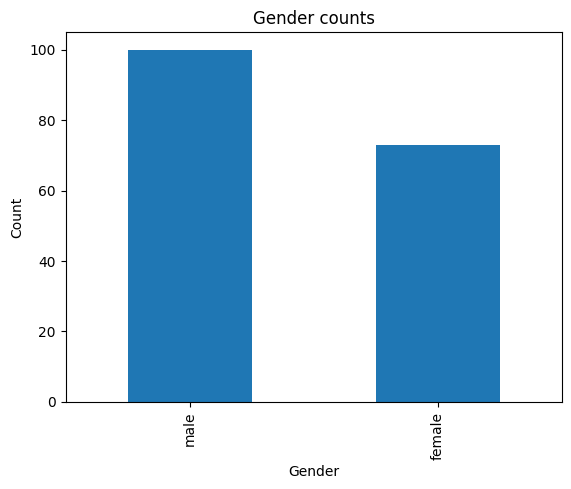

wave
Wave 1       22
Wave 2       69
Wave 3       35
Post-1995    16
Name: count, dtype: int64

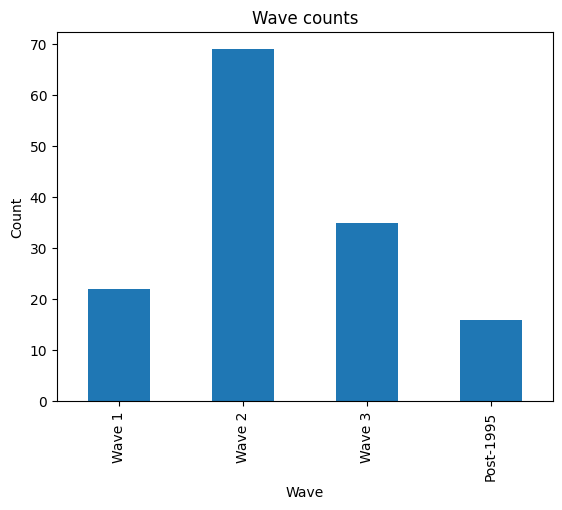

language_spoken
English    121
Name: count, dtype: int64

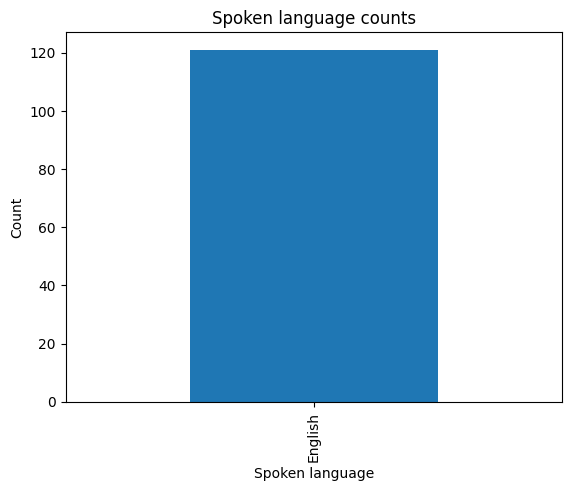

language_written
English       178
Vietnamese      3
Cantonese       1
Name: count, dtype: int64

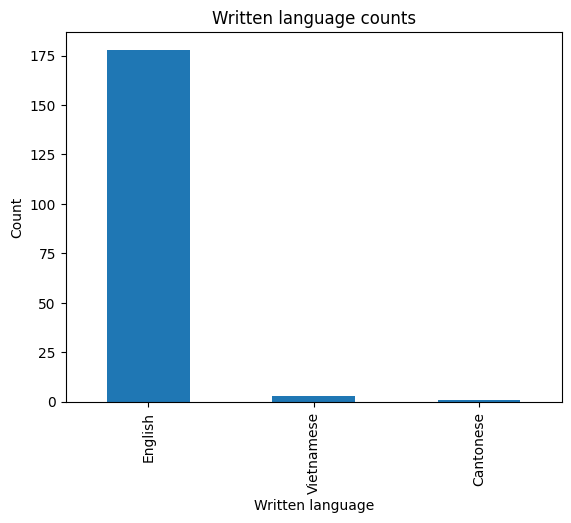

generation
1st generation     71
1.5 generation     33
1.75 generation     7
2nd generation      6
Name: count, dtype: int64

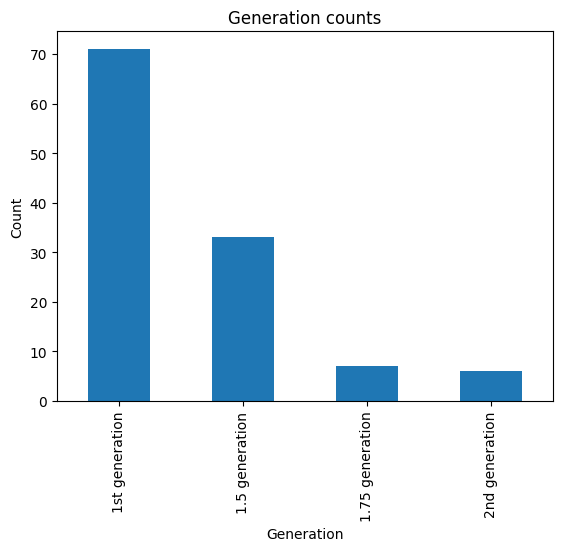

count    117.000000
mean      23.675214
std       14.629817
min        0.000000
25%       12.000000
50%       22.000000
75%       35.000000
max       65.000000
Name: age, dtype: float64

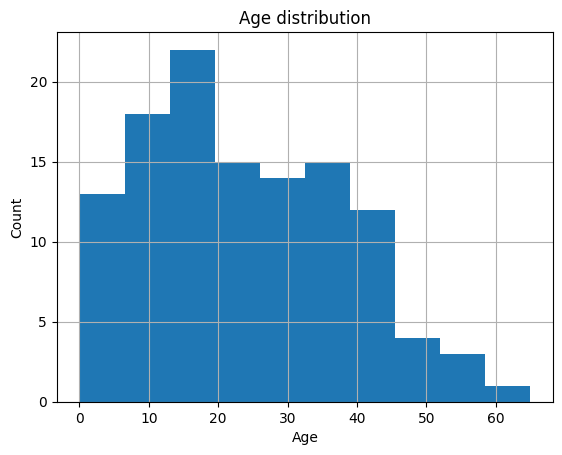

In [120]:
# Exploratory data analysis
unique_data = df_unique_interviews
display(unique_data.describe())

# Counts
unique_data['gender'].value_counts().plot(kind='bar')
display(unique_data['gender'].value_counts())
plt.title('Gender counts')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Counts
wave_order = ['Wave 1', 'Wave 2', 'Wave 3', 'Post-1995']
unique_data['wave'].value_counts().reindex(unique_data['wave'].value_counts().index[::-1]).sort_index().reindex(wave_order).plot(kind='bar')
display(unique_data['wave'].value_counts().reindex(unique_data['wave'].value_counts().index[::-1]).sort_index().reindex(wave_order))
plt.title('Wave counts')
plt.xlabel('Wave')
plt.ylabel('Count')
plt.xticks(range(len(wave_order)), wave_order)
plt.show()

# Counts
unique_data['language_spoken'].value_counts().plot(kind='bar')
display(unique_data['language_spoken'].value_counts())
plt.title('Spoken language counts')
plt.xlabel('Spoken language')
plt.ylabel('Count')
plt.show()

# Counts
unique_data['language_written'].value_counts().plot(kind='bar')
display(unique_data['language_written'].value_counts())
plt.title('Written language counts')
plt.xlabel('Written language')
plt.ylabel('Count')
plt.show()

# Counts
unique_data['generation'].value_counts().plot(kind='bar')
display(unique_data['generation'].value_counts())
plt.title('Generation counts')
plt.xlabel('Generation')
plt.ylabel('Count')
plt.show()

# Age
display(unique_data['age'].describe())

# Histogram
unique_data['age'].hist(bins=10)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


In [116]:
# Count the amount of male, female narrators for each of the waves
for wave in df_unique_interviews.wave.unique():
    # Filter the dataframe for the current wave
    df_wave = df_unique_interviews[df_unique_interviews.wave == wave]
    # Count the number of male and female narrators for the current wave
    male_narrators = df_wave[df_wave.gender == 'male'].shape[0]
    female_narrators = df_wave[df_wave.gender == 'female'].shape[0]
    # Print the results for the current wave
    print(f"Wave {wave}: {male_narrators} male narrators, {female_narrators} female narrators")


Wave Wave 1: 15 male narrators, 7 female narrators
Wave Wave 2: 31 male narrators, 37 female narrators
Wave Post-1995: 9 male narrators, 6 female narrators
Wave Wave 3: 20 male narrators, 12 female narrators
Wave nan: 0 male narrators, 0 female narrators
